In [4]:
import sys
import os
import numpy as np
from matplotlib import pyplot as plt

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost import FrostModel
from frost_evaporator.air import AirModel
from frost_evaporator.refrigerant import RefrigerantModel, propane_RP
from frost_evaporator.heat_mass_transfer import HeatMassTransferModel
from frost_evaporator.thermo import ThermoModel



#############################################################################
# Define Parameters
#############################################################################
params = FrostEvaporatorParameters(
    # General
    time_step=1.0,  # [s]
    gravity=9.81,  # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="jonas_diss",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="A",

    # Fan and Air Side Pressure Loss Parameters
    # hydraulic_fan_power=10.0,  # [W]
    pressure_loss_fit_factor=30.0,  # [-]

    # Geometrie Parameters
    fin_pitch=0.008,  # [m]
    fin_height=0.08,  # [m]
    fin_length=0.08,  # [m]
    fin_thickness=0.00012,  # [m]
    fin_amount=20,  # [-]
    fin_thermal_conductivity=200.0,  # [W/mK]
    tube_outer_diameter=0.010,  # [m]
    tube_inner_diameter=0.006,  # [m]
    tube_layers=2,  # [-]
    tubes_per_layer=2,  # [-]
    tube_thermal_conductivity=400, # [W/mK]

    alpha_0=4300.0,  # [W/m^2K] - 4300 for propane, used for two phase htc (VDI H2 Tab. 1)
)

#############################################################################
# Define Inputs
#############################################################################
refrigerant_inputs = RefrigerantInputs(
    h_in = 265000.0,  # [J/kg]
    p_eva = 3.0e5,  # [Pa]
    m_dot= 0.005,  # [kg/s]
)

# Define the inputs for the frost evaporator
air_inputs = AirInputs(
    T_in  = 280.0,  # [K]
    p_in  = 101325.0,  # [Pa]
    W_in  = 0.006,  # [kg/kg]
    )

inputs = FrostEvaporatorInputs(
    air_inputs   = air_inputs,
    refrigerant_inputs = refrigerant_inputs
)



#############################################################################
# Create Models
#############################################################################
frost_model = FrostModel(params)
air_model   = AirModel(params)
refrigerant_model = RefrigerantModel(params, propane_RP)
hmt_model = HeatMassTransferModel(params)
thermo_model = ThermoModel(params)



# Create the initial state
state = FrostEvaporatorState()
state.hmt.set("T_frost_surface", 268)

state.air.set("T_out", inputs.air.T_in)
state.air.set("W_out", inputs.air.W_in)
state.air.set("reynolds", 2000)

state.refrigerant.set("h_out", inputs.refrigerant.h_in + 100.0)


frost_model.step_forward(state, inputs)

states_history = []
T_frost_surface_history_all = []
from tqdm import tqdm



# for j in tqdm(range(5000)):
#     converged = False  # Flag to track if we found a stable solution
    
#     # --- 2. Inner loop to converge ---
#     for i in range(200):
#         T_prev = state.hmt.T_frost_surface
#         # Run your model updates
#         frost_model.update_properties(state, inputs)
#         air_model.update_properties(state, inputs)
#         refrigerant_model.update_properties(state, inputs)
#         hmt_model.update_properties(state, inputs)
#         thermo_model.update_properties(state, inputs)
        
#         # Get the *new* value
#         T_new = state.hmt.T_frost_surface

#         T_frost_surface_history_all.append(T_new)
        
#         # --- 3. The convergence check ---
#         error = abs(T_new - T_prev)
#         if error < 1e-2 :
#             converged = True  # We found a stable solution!
#             break             # Exit the inner loop
    
#     # --- 4. Handle non-convergence ---
#     if not converged:
#         print(f"\n\n\n\n!!! CRASH REPORT bei Zeitschritt j={j} !!!")
#         print(f"Letztes Residuum: {abs(T_new - T_prev)}\n")
#         print(params.__str__())
#         print("\n\n\n\n")
#         print(inputs.__str__())
#         print("\n\n\n\n")
#         print(state.__str__())        
#         break 

#     states_history.append(state.copy())
    
#     # Now that we have a converged state, take the physical step forward
#     frost_model.step_forward(state, inputs)

# print("\n\n\n\nSimulation complete.")

# print("\n\nFinal State:\n")

# print(params.__str__())
# print("\n\n\n\n")
# print(inputs.__str__())
# print("\n\n\n\n")
# print(state.__str__())



import time
from tqdm import tqdm

# 1. Setup für das Tracking der Zeiten
execution_times = {
    "frost_model": 0.0,
    "air_model": 0.0,
    "refrigerant_model": 0.0,
    "hmt_model": 0.0,
    "thermo_model": 0.0
}

for j in tqdm(range(4000)):
    converged = False  # Flag to track if we found a stable solution
    
    # --- 2. Inner loop to converge ---
    for i in range(200):
        T_prev = state.hmt.T_frost_surface
        
        # --- Run your model updates with TIMING ---
        
        # Messung Frost Model
        t_start = time.perf_counter()
        frost_model.update_properties(state, inputs)
        execution_times["frost_model"] += time.perf_counter() - t_start
        
        # Messung Air Model
        t_start = time.perf_counter()
        air_model.update_properties(state, inputs)
        execution_times["air_model"] += time.perf_counter() - t_start
        
        # Messung Refrigerant Model
        t_start = time.perf_counter()
        refrigerant_model.update_properties(state, inputs)
        execution_times["refrigerant_model"] += time.perf_counter() - t_start
        
        # Messung HMT Model
        t_start = time.perf_counter()
        hmt_model.update_properties(state, inputs)
        execution_times["hmt_model"] += time.perf_counter() - t_start
        
        # Messung Thermo Model
        t_start = time.perf_counter()
        thermo_model.update_properties(state, inputs)
        execution_times["thermo_model"] += time.perf_counter() - t_start
        
        # ------------------------------------------
        
        # Get the *new* value
        T_new = state.hmt.T_frost_surface

        T_frost_surface_history_all.append(T_new)
        
        # --- 3. The convergence check ---
        error = abs(T_new - T_prev)
        if error < 1e-2 :
            converged = True  # We found a stable solution!
            break             # Exit the inner loop
    
    # --- 4. Handle non-convergence ---
    if not converged:
        print(f"\n\n\n\n!!! CRASH REPORT bei Zeitschritt j={j} !!!")
        print(f"Letztes Residuum: {abs(T_new - T_prev)}\n")
        print(params.__str__())
        print("\n\n\n\n")
        print(inputs.__str__())
        print("\n\n\n\n")
        print(state.__str__())        
        break 

    states_history.append(state.copy())
    
    # Now that we have a converged state, take the physical step forward
    frost_model.step_forward(state, inputs)

# --- AUSWERTUNG AM ENDE ---
print("\n" + "="*30)
print("PERFORMANCE ANALYSE (Gesamtlaufzeit pro Modell)")
print("="*30)

# Sortieren von langsam nach schnell
sorted_times = sorted(execution_times.items(), key=lambda item: item[1], reverse=True)
total_measured_time = sum(execution_times.values())

for model_name, duration in sorted_times:
    percent = (duration / total_measured_time) * 100 if total_measured_time > 0 else 0
    print(f"{model_name:<20}: {duration:.4f} s ({percent:.1f}%)")
print("="*30)

Model initialized with fluid: Propane


  0%|          | 0/4000 [00:00<?, ?it/s]

100%|██████████| 4000/4000 [00:19<00:00, 207.60it/s]


PERFORMANCE ANALYSE (Gesamtlaufzeit pro Modell)
refrigerant_model   : 7.0875 s (44.4%)
air_model           : 4.1692 s (26.1%)
thermo_model        : 2.8962 s (18.2%)
hmt_model           : 1.7355 s (10.9%)
frost_model         : 0.0685 s (0.4%)


# Simulation of Paper: "First-principles modeling of frost accumulation on fan-supplied tube-fin evaporators"

In [1]:
import sys
import os
import numpy as np
from matplotlib import pyplot as plt

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost import FrostModel
from frost_evaporator.air import AirModel
from frost_evaporator.refrigerant import RefrigerantModel, propane_RP
from frost_evaporator.heat_mass_transfer import HeatMassTransferModel
from frost_evaporator.thermo import ThermoModel



#############################################################################
# Define Parameters
#############################################################################
params = FrostEvaporatorParameters(
    # General
    time_step=1.0,  # [s]
    gravity=9.81,  # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="da_silva_paper",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="A",

    # Fan and Air Side Pressure Loss Parameters
    # hydraulic_fan_power=10.0,  # [W] ------------------------------
    pressure_loss_fit_factor=25.0,  # [-] ------------------------------

    # Geometrie Parameters
    # Calculated: 4 fins/cm = 0.25 cm pitch = 2.5 mm
    fin_pitch=0.0025,  # [m]
    # Paper: Height = 152 mm
    fin_height=0.152,  # [m]
    # Paper: Depth (air flow length) = 45 mm
    fin_length=0.045,  # [m]
    # Paper: 0.2 mm thickness
    fin_thickness=0.0002,  # [m]
    # Calculated: Width (320mm) / Pitch (2.5mm) = 128 fins
    fin_amount=128,  # [-]
    # Paper: "Aluminum alloy" (Standard value usually ~200-220)
    fin_thermal_conductivity=200.0,  # [W/mK]
    # Paper: 10 mm Outer Diameter
    tube_outer_diameter=0.010,  # [m]
    # Paper: 1 mm wall thickness -> ID = 10 - 2*1 = 8 mm
    tube_inner_diameter=0.008,  # [m]
    # Paper: "Two rows"
    tube_layers=2,  # [-]
    # Paper: "Six tubes per row"
    tubes_per_layer=6,  # [-]
    # Paper: Copper tubes (Standard value ~385-400)
    tube_thermal_conductivity=400, # [W/mK]

    alpha_0=4300.0,  # [W/m^2K] - 4300 for propane, used for two phase htc (VDI H2 Tab. 1)
)

#############################################################################
# Define Inputs
#############################################################################

# Useless, because Paper uses constant surface temp
refrigerant_inputs = RefrigerantInputs(
    h_in = 0.0,  # [J/kg]
    p_eva = 0.0,  # [Pa]
    m_dot= 0.0,  # [kg/s]
)

# Define the inputs for the frost evaporator
# Values below are for "Test 2" (Standard Commercial conditions from Table 1)
air_inputs = AirInputs(
    T_in  = 273.15 + 7,  # [K]
    p_in  = 101325.0,  # [Pa]
    R_in  = 0.85,  # [kg/kg]
    )

inputs = FrostEvaporatorInputs(
    air_inputs   = air_inputs,
    refrigerant_inputs = refrigerant_inputs
)



#############################################################################
# Create Models
#############################################################################
frost_model = FrostModel(params)
air_model   = AirModel(params)
refrigerant_model = RefrigerantModel(params, propane_RP)
hmt_model = HeatMassTransferModel(params)
thermo_model = ThermoModel(params)



# Create the initial state
state = FrostEvaporatorState()
state.hmt.set("T_frost_surface", 268)

state.air.set("T_out", inputs.air.T_in)
# state.air.set("W_out", inputs.air.W_in)
state.air.set("reynolds", 2000)
state.air.set("T_dew_point", 260)


state.refrigerant.set("h_out", inputs.refrigerant.h_in + 100.0)

# DELETE
T_surface_temporary = 273.15 - 10
state.refrigerant.set("T_in", T_surface_temporary)
state.refrigerant.set("T_out", T_surface_temporary)

frost_model.step_forward(state, inputs)

states_history = []
T_frost_surface_history_all = []
history_residual = []
total_iterations = 0
from tqdm import tqdm

simulation_duration = 10 # [s]

for j in tqdm(range(simulation_duration)):
    converged = False  # Flag to track if we found a stable solution
    
    # Inner loop to converge
    for i in range(200):

        # Get the *previous* value
        T_prev = state.hmt.T_frost_surface

        # Run your model updates
        frost_model.update_properties(state, inputs)
        air_model.update_properties(state, inputs)
        # refrigerant_model.update_properties(state, inputs)
        hmt_model.update_properties(state, inputs)
        thermo_model.update_properties(state, inputs)
        
        # Get the *new* value
        T_new = state.hmt.T_frost_surface
        T_frost_surface_history_all.append(T_new)
        
        # The convergence check
        res = abs(T_new - T_prev)      
        history_residual.append(res)  

        error = abs(T_new - T_prev)
        if error < 1e-3 :
            converged = True  # We found a stable solution!
            total_iterations += i+1
            break             # Exit the inner loop
    
    # Handle non-convergence
    if not converged:
        print(f"\n\n\n\n!!! CRASH REPORT bei Zeitschritt j={j} !!!")
        print(f"Letztes Residuum: {abs(T_new - T_prev)}\n")        
        break 

    if state.air.m_dot_humid < 1e-3:
        print(f"\n\n\n\n!!! Air Choke bei Zeitschritt j={j} !!!")
        print(f"Letzter Massenstorm: {state.air.m_dot_humid}\n")        
        break 

    states_history.append(state.copy())
    
    # Now that we have a converged state, take the physical step forward
    frost_model.step_forward(state, inputs)

print("\n\nFinal State:\n")
print(f"Average Iterations per Timestep: {(total_iterations/simulation_duration)} \n" )
print(params.__str__())
print("\n\n\n\n")
print(inputs.__str__())
print("\n\n\n\n")
print(state.__str__())

# plt.figure()
# plt.plot(history_residual)
# plt.yscale('log')
# plt.title("History of Residuals")
# plt.show()

Model initialized with fluid: Propane


100%|██████████| 10/10 [00:00<00:00, 33.58it/s]



Final State:

Average Iterations per Timestep: 6.2 

FrostEvaporatorParameters:
time_step=1.0 s (Simulation time step for evaporator model)
gravity=9.81 m/s^2 (Gravitational acceleration)
frost_density_correlation_choice=da_silva_paper - (Choice of correlation for frost density)
frost_thickness_correlation_choice=jonas_diss - (Choice of correlation for frost thickness)
frost_conductivity_correlation_choice=A - (Choice of correlation for frost thermal conductivity)
pressure_loss_fit_factor=25.0 - (Fit factor for air-side pressure loss calculations)
ambient_pressure=101325.0 Pa (Ambient pressure for air-side calculations)
fin_pitch=0.0025 m (Spacing between fins (from center to center))
fin_height=0.152 m (Height of each fin)
fin_length=0.045 m (Length of each fin)
fin_thickness=0.0002 m (Thickness of each fin)
fin_amount=128 - (Total number of fins)
fin_thermal_conductivity=200.0 W/m/K (Thermal conductivity of fin material)
tube_outer_diameter=0.01 m (Outer diameter of tubes)
tube_inn

In [2]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# ---------------------------------------------------------
# 1. PREPARE DATA
# ---------------------------------------------------------
n_steps = len(states_history)
dt = params.time_step 
# Convert time to minutes for the axis
time_axis = [i * dt / 60 for i in range(n_steps)]

data = {
    # --- TEMPS ---
    'T_air_in': inputs.air.T_in, 
    'T_air_out': [s.air.T_out for s in states_history],
    'T_frost_surf': [s.hmt.T_frost_surface for s in states_history],
    'T_refrigerant_in' : [s.refrigerant.T_in for s in states_history],
    'T_refrigerant_out' : [s.refrigerant.T_out for s in states_history],

    # --- HUMIDITY ---
    'W_in': state.air.W_in, 
    'W_out': [s.air.W_out for s in states_history],
    'W_frost_sat': [s.air.W_frost_sat for s in states_history],
    
    # --- HEAT TRANSFER ---
    'Q_dot_total': [s.hmt.Q_dot_total for s in states_history],
    'Q_dot_sens': [s.hmt.Q_dot_sens for s in states_history],

    # --- FROST PROPERTIES ---
    'thickness': [s.frost.thickness for s in states_history],
    'density': [s.frost.density for s in states_history],
    'space': [s.frost.space_between_frost for s in states_history],
    'mass': [s.frost.mass for s in states_history],
    
    # --- PHYSICS / FLOW ---
    'h_conv': [s.air.h_conv for s in states_history],
    'eta_fin': [s.hmt.eta_fin for s in states_history],
    'velocity': [s.air.velocity for s in states_history],
    'm_dot': [s.air.m_dot_humid for s in states_history],
    'p_delta': [s.air.p_in - params.ambient_pressure for s in states_history],
    'vol_flow': [3600 * s.air.m_dot_humid / s.air.density_avg for s in states_history]    # Formula: 3600 * m_dot / density
}

df = pd.DataFrame(data)
df['Time'] = time_axis
df.set_index('Time', inplace=True)

# ---------------------------------------------------------
# 2. PLOT CONFIGURATION (Reordered for Logic)
# ---------------------------------------------------------
plots_config = [
    # --- ROW 1: MACRO THERMODYNAMICS ---
    (1, 1, ['T_air_in', 'T_air_out', 'T_frost_surf', 'T_refrigerant_in', 'T_refrigerant_out'], "Temperatures [K]"), 
    (1, 2, ['Q_dot_total', 'Q_dot_sens'], "Heat Transfer [W]"),
    (1, 3, ['p_delta'], "Pressure Difference [Pa]"),
    
    # --- ROW 2: AERODYNAMICS (FLOW) ---
    (2, 1, ['vol_flow'], "Volume Flow [m³/h]"), # <--- NEW PLOT
    (2, 2, ['velocity'], "Air Velocity [m/s]"),
    (2, 3, ['m_dot'], "Mass Flow [kg/s]"),
    
    # --- ROW 3: BOUNDARY LAYER & HUMIDITY ---
    (3, 1, ['W_in', 'W_out', 'W_frost_sat'], "Abs. Humidity [kg/kg]"),
    (3, 2, ['h_conv'], "Air h_conv [W/m²K]"),
    (3, 3, ['eta_fin'], "Fin Efficiency [-]"),
    
    # --- ROW 4: FROST MICRO-STATE ---
    (4, 1, ['thickness'], "Frost Thickness [m]"),
    (4, 2, ['density'], "Frost Density [kg/m³]"),
    (4, 3, ['space'], "Space Between Frost [m]"),

    # --- ROW 5: ---
    (5, 1, ['mass'], "Frost Mass [kg]")
]

fig = make_subplots(
    rows=5, cols=3, 
    subplot_titles=[p[3] for p in plots_config],
    vertical_spacing=0.1, horizontal_spacing=0.05
)

for row, col, cols_to_plot, title in plots_config:
    for col_name in cols_to_plot:
        # Optional: styling for T_dew_point if you add it back later
        line_style = dict(dash='dot', width=2) if col_name == 'T_dew_point' else dict()
        
        fig.add_trace(
            go.Scatter(
                x=df.index, y=df[col_name], name=col_name,
                line=line_style,
                legendgroup=title, legendgrouptitle_text=title
            ),
            row=row, col=col
        )

# ---------------------------------------------------------
# 3. LAYOUT & INTERACTIVITY
# ---------------------------------------------------------
fig.update_layout(
    height=1800, width=1400, 
    title_text="Simulation Debug Overview",
    hovermode="x unified",
    showlegend=False
)

fig.update_xaxes(matches='x', title_text="Time [min]")
fig.update_yaxes(rangemode="tozero", row=4, col=3)
fig.show()

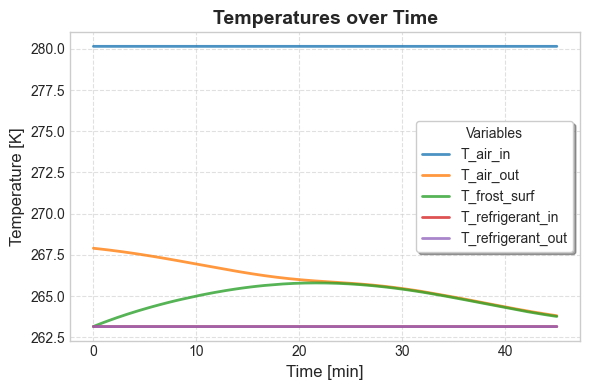

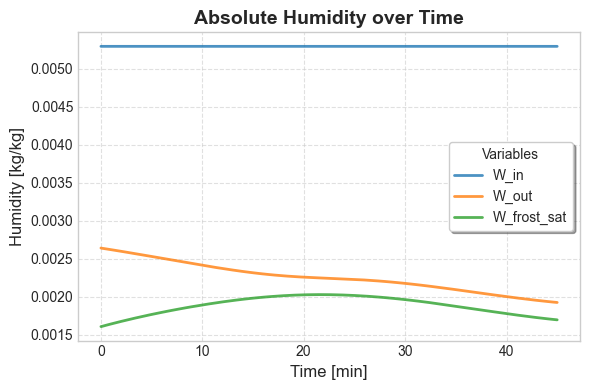

In [18]:
import matplotlib.pyplot as plt

# ==========================================
# 1. TEMPERATURES PLOT
# ==========================================
plt.figure(figsize=(6, 4))

# List of temperature columns to plot
temp_cols = [
    'T_air_in', 
    'T_air_out', 
    'T_frost_surf', 
    'T_refrigerant_in', 
    'T_refrigerant_out'
]

for col in temp_cols:
    # Plot each column against the index (Time)
    plt.plot(df.index, df[col], label=col, linewidth=2, alpha=0.8)

plt.title("Temperatures over Time", fontsize=14, fontweight='bold')
plt.xlabel("Time [min]", fontsize=12)
plt.ylabel("Temperature [K]", fontsize=12)

# Legend configuration
plt.legend(
    loc='best',           # Automatically find the best position
    frameon=True,         # Draw a box around the legend
    shadow=True,          # Add a shadow to the box
    fancybox=True,        # Rounded corners
    fontsize=10,
    title="Variables"
)

plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# ==========================================
# 2. HUMIDITY PLOT
# ==========================================
plt.figure(figsize=(6, 4))

# List of humidity columns to plot
hum_cols = [
    'W_in', 
    'W_out', 
    'W_frost_sat'
]

for col in hum_cols:
    plt.plot(df.index, df[col], label=col, linewidth=2, alpha=0.8)

plt.title("Absolute Humidity over Time", fontsize=14, fontweight='bold')
plt.xlabel("Time [min]", fontsize=12)
plt.ylabel("Humidity [kg/kg]", fontsize=12)

# Legend configuration
plt.legend(
    loc='best',
    frameon=True, 
    shadow=True, 
    fancybox=True,
    fontsize=10,
    title="Variables"
)

plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Run Multiple Simulations and Plot (Da Silva)

In [3]:
import sys
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm import tqdm

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

# Import your custom modules
from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost import FrostModel
from frost_evaporator.air import AirModel
from frost_evaporator.refrigerant import RefrigerantModel, propane_RP
from frost_evaporator.heat_mass_transfer import HeatMassTransferModel
from frost_evaporator.thermo import ThermoModel

#############################################################################
# 1. Define Global Parameters (Hardware/Geometry - constant for all tests)
#############################################################################
params = FrostEvaporatorParameters(
    # General
    time_step=1.0,  # [s]
    gravity=9.81,   # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="da_silva_paper",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="A",

    # Fan and Air Side Pressure Loss Parameters
    pressure_loss_fit_factor=25.0,  # [-]

    # Geometry Parameters
    fin_pitch=0.0025,               # [m]
    fin_height=0.152,               # [m]
    fin_length=0.045,               # [m]
    fin_thickness=0.0002,           # [m]
    fin_amount=128,                 # [-]
    fin_thermal_conductivity=200.0, # [W/mK]
    tube_outer_diameter=0.010,      # [m]
    tube_inner_diameter=0.008,      # [m]
    tube_layers=2,                  # [-]
    tubes_per_layer=6,              # [-]
    tube_thermal_conductivity=400,  # [W/mK]

    alpha_0=4300.0,  # [W/m^2K]
)

#############################################################################
# 2. Define the Simulation Function
#############################################################################
def run_simulation_case(case_name, T_air_C, RH_in, T_surf_C, duration_mins, color):
    """
    Runs the simulation for a specific set of boundary conditions.
    Returns a DataFrame of results and the assigned color for plotting.
    """
    print(f"--- Starting Simulation: {case_name} ---")
    print(f"Inputs: T_air={T_air_C}°C, RH={RH_in*100}%, T_surf={T_surf_C}°C, Time={duration_mins}min")

    # --- Setup Inputs ---
    # Dummy refrigerant inputs (since T_surface is constant/forced)
    refrigerant_inputs = RefrigerantInputs(h_in=0.0, p_eva=0.0, m_dot=0.0)

    air_inputs = AirInputs(
        T_in = 273.15 + T_air_C,  # Convert to K
        p_in = 101325.0,          # [Pa]
        R_in = RH_in,             # [-]
    )

    inputs = FrostEvaporatorInputs(
        air_inputs=air_inputs,
        refrigerant_inputs=refrigerant_inputs
    )

    # --- Instantiate Models (Fresh for each run) ---
    frost_model = FrostModel(params)
    air_model   = AirModel(params)
    # refrigerant_model = RefrigerantModel(params, propane_RP) # Not strictly needed if forcing T_surf
    hmt_model = HeatMassTransferModel(params)
    thermo_model = ThermoModel(params)

    # --- Initial State ---
    state = FrostEvaporatorState()
    state.hmt.set("T_frost_surface", 268) # Start slightly below freezing
    state.air.set("T_out", inputs.air.T_in)
    state.air.set("reynolds", 2000)
    state.air.set("T_dew_point", 260)
    state.refrigerant.set("h_out", inputs.refrigerant.h_in + 100.0)

    # FORCE SURFACE TEMPERATURE (The paper's method)
    T_surface_kelvin = 273.15 + T_surf_C
    state.refrigerant.set("T_in", T_surface_kelvin)
    state.refrigerant.set("T_out", T_surface_kelvin)

    # Initial Step
    frost_model.step_forward(state, inputs)

    # --- Time Loop ---
    states_history = []
    simulation_duration_sec = int(duration_mins * 60)
    
    # Use a unique description for the progress bar
    for j in tqdm(range(simulation_duration_sec), desc=case_name):
        converged = False
        
        # Inner loop to converge
        for i in range(200):
            T_prev = state.hmt.T_frost_surface

            # Run model updates
            frost_model.update_properties(state, inputs)
            air_model.update_properties(state, inputs)
            hmt_model.update_properties(state, inputs)
            thermo_model.update_properties(state, inputs)
            
            T_new = state.hmt.T_frost_surface
            
            if abs(T_new - T_prev) < 1e-3:
                converged = True
                break
        
        if not converged:
            print(f"!!! CRASH in {case_name} at step {j} !!! Residuum: {abs(T_new - T_prev)}")
            break 

        if state.air.m_dot_humid < 1e-3:
            print(f"!!! Air Choke in {case_name} at step {j} !!!")
            break 

        states_history.append(state.copy())
        
        # Physical step forward
        frost_model.step_forward(state, inputs)

    # --- Post-Process Data into DataFrame ---
    # Create time axis in Minutes
    time_axis = [i * params.time_step / 60 for i in range(len(states_history))]

    data = {
        # Temps
        'T_air_in': inputs.air.T_in, 
        'T_air_out': [s.air.T_out for s in states_history],
        'T_frost_surf': [s.hmt.T_frost_surface for s in states_history],
        'T_refrigerant_in' : [s.refrigerant.T_in for s in states_history],
        'T_refrigerant_out' : [s.refrigerant.T_out for s in states_history],
        
        # Humidity
        'W_in': state.air.W_in, 
        'W_out': [s.air.W_out for s in states_history],
        'W_frost_sat': [s.air.W_frost_sat for s in states_history],
        
        # Heat Transfer
        'Q_dot_total': [s.hmt.Q_dot_total for s in states_history],
        'Q_dot_sens': [s.hmt.Q_dot_sens for s in states_history],
        
        # Frost Props
        'thickness': [s.frost.thickness for s in states_history],
        'density': [s.frost.density for s in states_history],
        'space': [s.frost.space_between_frost for s in states_history],
        'mass': [s.frost.mass for s in states_history],
        
        # Flow/Physics
        'h_conv': [s.air.h_conv for s in states_history],
        'eta_fin': [s.hmt.eta_fin for s in states_history],
        'velocity': [s.air.velocity for s in states_history],
        'm_dot': [s.air.m_dot_humid for s in states_history],
        'p_delta': [s.air.p_in - params.ambient_pressure for s in states_history],
        # Vol flow in m3/h
        'vol_flow': [3600 * s.air.m_dot_humid / s.air.density_avg for s in states_history]
    }
    
    df = pd.DataFrame(data)
    df['Time'] = time_axis
    df.set_index('Time', inplace=True)
    
    return df, color

#############################################################################
# 3. Execution Block
#############################################################################

# Define the 3 simulations from the paper
# Format: (Name, T_air_in_C, RH_in, T_surf_C, Duration_mins, PlotColor)
simulations_config = [
    ("Case 1 (7°C, 85%)",   7.0, 0.85, -10.0, 42,  "red"),
    ("Case 2 (2.5°C, 85%)", 2.5, 0.85, -10.0, 64,  "blue"),
    ("Case 3 (2.5°C, 72%)", 2.5, 0.72, -5.0,  120, "green"),
]

results = {}

# Run them all
for sim_conf in simulations_config:
    name, t_in, rh, t_surf, dur, col = sim_conf
    df_res, color_res = run_simulation_case(name, t_in, rh, t_surf, dur, col)
    results[name] = {'df': df_res, 'color': color_res}


#############################################################################
# 4. Plotting (Combined)
#############################################################################

# Plot Configuration (Row, Col, Variables, Title)
plots_config = [
    # --- ROW 1 ---
    (1, 1, ['T_air_in', 'T_air_out', 'T_frost_surf', 'T_refrigerant_in'], "Temperatures [K]"), 
    (1, 2, ['Q_dot_total', 'Q_dot_sens'], "Heat Transfer [W]"),
    (1, 3, ['p_delta'], "Pressure Difference [Pa]"),
    
    # --- ROW 2 ---
    (2, 1, ['vol_flow'], "Volume Flow [m³/h]"),
    (2, 2, ['velocity'], "Air Velocity [m/s]"),
    (2, 3, ['m_dot'], "Mass Flow [kg/s]"),
    
    # --- ROW 3 ---
    (3, 1, ['W_in', 'W_out', 'W_frost_sat'], "Abs. Humidity [kg/kg]"),
    (3, 2, ['h_conv'], "Air h_conv [W/m²K]"),
    (3, 3, ['eta_fin'], "Fin Efficiency [-]"),
    
    # --- ROW 4 ---
    (4, 1, ['thickness'], "Frost Thickness [m]"),
    (4, 2, ['density'], "Frost Density [kg/m³]"),
    (4, 3, ['space'], "Space Between Frost [m]"),

    # --- ROW 5 ---
    (5, 1, ['mass'], "Frost Mass [kg]")
]

fig = make_subplots(
    rows=5, cols=3, 
    subplot_titles=[p[3] for p in plots_config],
    vertical_spacing=0.08, horizontal_spacing=0.05
)

# Iterate over simulation results
for case_name, res_data in results.items():
    df = res_data['df']
    color = res_data['color']
    
    # Iterate over plot configuration
    for row, col, cols_to_plot, title in plots_config:
        for col_name in cols_to_plot:
            
            # Styling: Dashed lines for specific secondary variables to distinguish them
            line_dash = 'solid'
            if 'out' in col_name and 'air' in col_name: line_dash = 'dot'
            if 'sens' in col_name: line_dash = 'dot'
            if 'frost_sat' in col_name: line_dash = 'dash'
            
            # Construct a trace name: "Variable (Case Name)"
            trace_name = f"{col_name} ({case_name})"
            
            fig.add_trace(
                go.Scatter(
                    x=df.index, 
                    y=df[col_name], 
                    name=trace_name,
                    line=dict(color=color, dash=line_dash, width=1.5),
                    legendgroup=case_name, # Grouping allows toggling whole cases if desired
                    showlegend=(row==1 and col==1) # Only show legend once to avoid clutter? 
                    # Or remove 'showlegend=...' to show everything
                ),
                row=row, col=col
            )

# ---------------------------------------------------------
# Layout & Final Touches
# ---------------------------------------------------------
fig.update_layout(
    height=2000, width=1400, 
    title_text="Comparison of Frost Growth Simulations (Paper Reproduction)",
    hovermode="x unified",
    showlegend=False 
)

fig.update_xaxes(matches='x', title_text="Time [min]")
# Ensure space plot goes to zero
fig.update_yaxes(rangemode="tozero", row=4, col=3)

fig.show()

--- Starting Simulation: Case 1 (7°C, 85%) ---
Inputs: T_air=7.0°C, RH=85.0%, T_surf=-10.0°C, Time=42min


Case 1 (7°C, 85%): 100%|██████████| 2520/2520 [00:42<00:00, 59.16it/s] 


--- Starting Simulation: Case 2 (2.5°C, 85%) ---
Inputs: T_air=2.5°C, RH=85.0%, T_surf=-10.0°C, Time=64min


Case 2 (2.5°C, 85%): 100%|██████████| 3840/3840 [00:24<00:00, 154.10it/s]


--- Starting Simulation: Case 3 (2.5°C, 72%) ---
Inputs: T_air=2.5°C, RH=72.0%, T_surf=-5.0°C, Time=120min


Case 3 (2.5°C, 72%): 100%|██████████| 7200/7200 [00:46<00:00, 154.55it/s]


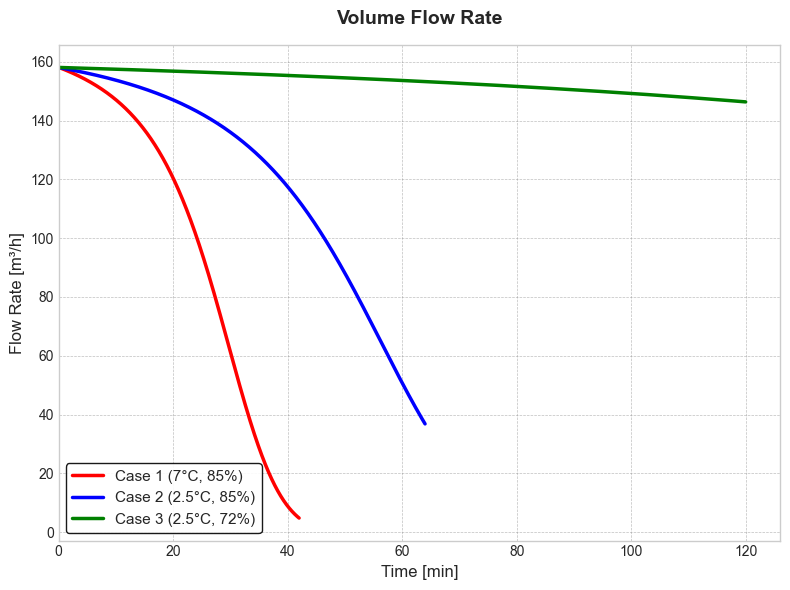

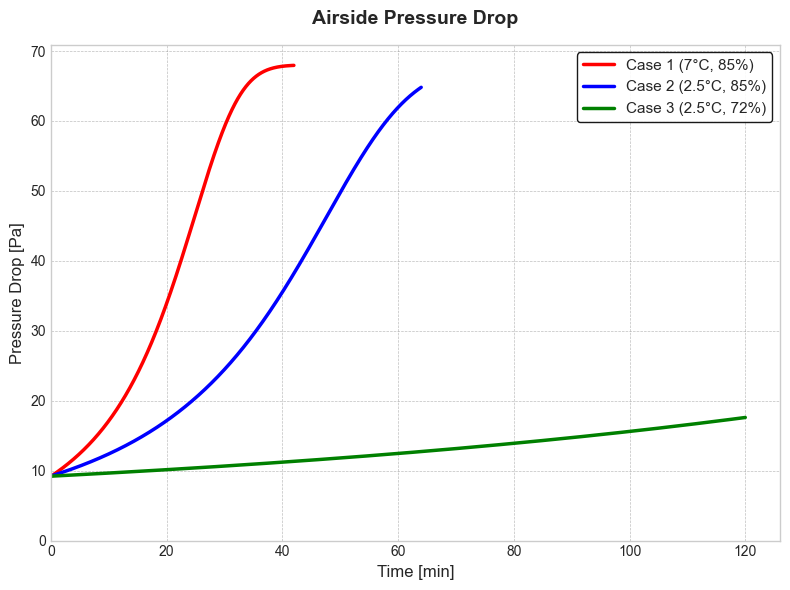

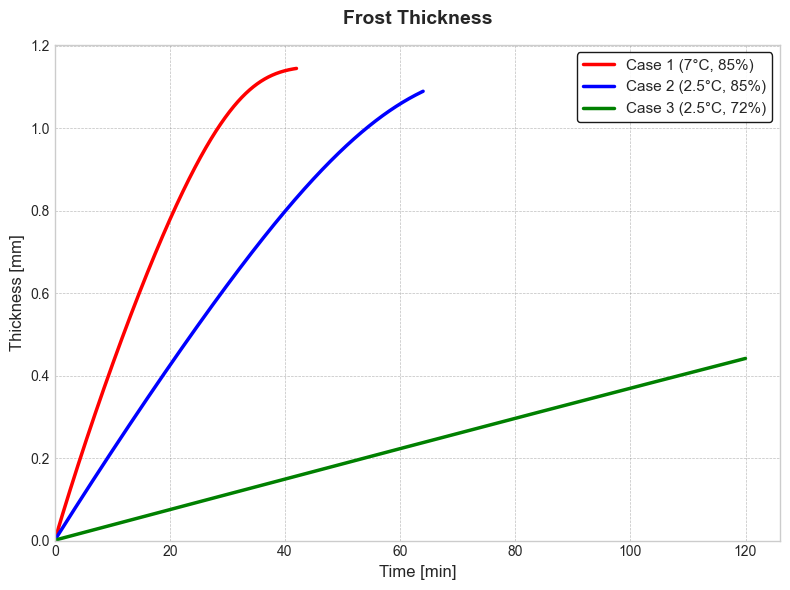

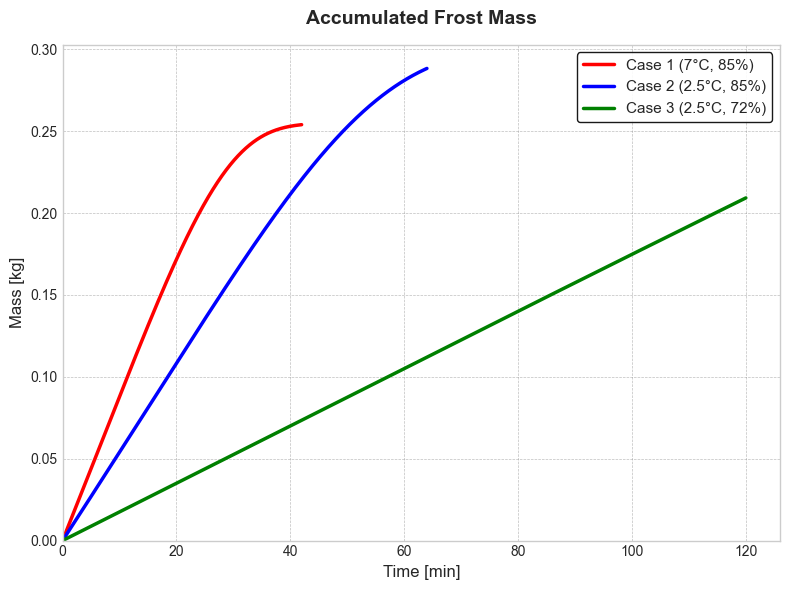

In [4]:
import matplotlib.pyplot as plt

# Optional: Set a clean style (if available, otherwise defaults are used)
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    # Fallback if specific style isn't available
    plt.style.use('fast')

# ---------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------
# (DataFrame_Column, Plot_Title, Y_Axis_Label, Unit_Multiplier)
plot_specs = [
    ('vol_flow',  "Volume Flow Rate",       "Flow Rate [m³/h]", 1.0),
    ('p_delta',   "Airside Pressure Drop",  "Pressure Drop [Pa]", 1.0),
    ('thickness', "Frost Thickness",        "Thickness [mm]",   1000.0), # m -> mm
    ('mass',      "Accumulated Frost Mass", "Mass [kg]",        1.0),
]

# ---------------------------------------------------------
# PLOTTING LOOP
# ---------------------------------------------------------
for col_name, title, y_label, multiplier in plot_specs:
    
    # Create a new figure for each plot
    plt.figure(figsize=(8, 6), dpi=100)
    
    # Loop through the results (Cases)
    for case_name, data in results.items():
        df = data['df']
        color = data['color']
        
        # Plot the line
        plt.plot(
            df.index, 
            df[col_name] * multiplier, 
            label=case_name, 
            color=color, 
            linewidth=2.5,
            linestyle='-'
        )

    # ---------------------------------------------------------
    # FORMATTING
    # ---------------------------------------------------------
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Time [min]", fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    
    # Grid configuration
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
    
    # Limits and Layout
    plt.xlim(left=0)
    if col_name in ['thickness', 'mass', 'p_delta']:
        plt.ylim(bottom=0)
        
    # Legend Configuration
    plt.legend(
        loc='best',         # Automatically finds the spot with least overlap
        fontsize=11, 
        frameon=True,       # Box around legend
        fancybox=True,      # Rounded corners
        framealpha=0.9,     # Slight transparency
        edgecolor='black'
    )
    
    plt.tight_layout()
    plt.show()

Model initialized with fluid: Propane


 49%|████▊     | 107/220 [00:04<00:04, 25.55it/s]

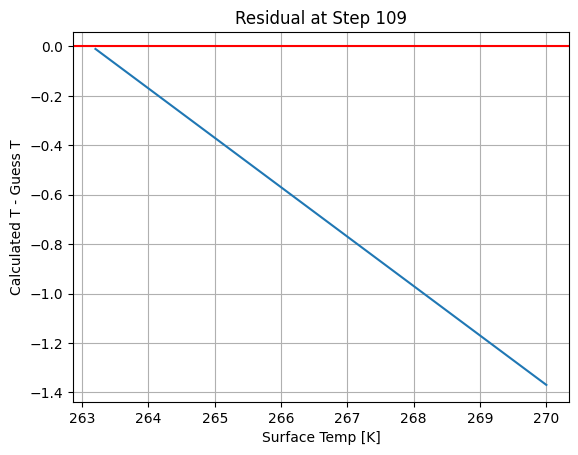

 90%|████████▉ | 197/220 [00:16<00:00, 28.68it/s]

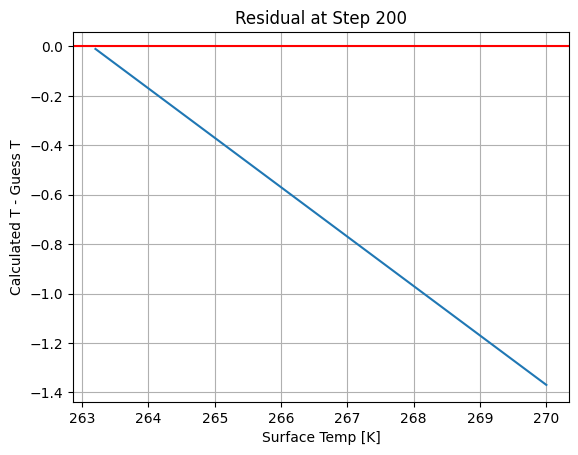

100%|██████████| 220/220 [00:25<00:00,  8.75it/s]



Final State:

FrostEvaporatorParameters:
time_step=1.0 s (Simulation time step for evaporator model)
gravity=9.81 m/s^2 (Gravitational acceleration)
frost_density_correlation_choice=jonas_diss - (Choice of correlation for frost density)
frost_thickness_correlation_choice=jonas_diss - (Choice of correlation for frost thickness)
frost_conductivity_correlation_choice=A - (Choice of correlation for frost thermal conductivity)
pressure_loss_fit_factor=50.0 - (Fit factor for air-side pressure loss calculations)
ambient_pressure=101325.0 Pa (Ambient pressure for air-side calculations)
fin_pitch=0.0025 m (Spacing between fins (from center to center))
fin_height=0.152 m (Height of each fin)
fin_length=0.045 m (Length of each fin)
fin_thickness=0.0002 m (Thickness of each fin)
fin_amount=128 - (Total number of fins)
fin_thermal_conductivity=200.0 W/m/K (Thermal conductivity of fin material)
tube_outer_diameter=0.01 m (Outer diameter of tubes)
tube_inner_diameter=0.008 m (Inner diameter of tube

In [9]:
import sys
import os
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import brentq
from tqdm import tqdm

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost import FrostModel
from frost_evaporator.air import AirModel
from frost_evaporator.refrigerant import RefrigerantModel, propane_RP
from frost_evaporator.heat_mass_transfer import HeatMassTransferModel
from frost_evaporator.thermo import ThermoModel



#############################################################################
# Define Parameters
#############################################################################
params = FrostEvaporatorParameters(
    # General
    time_step=1.0,  # [s]
    gravity=9.81,  # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="jonas_diss",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="A",

    # Fan and Air Side Pressure Loss Parameters
    # hydraulic_fan_power=10.0,  # [W] ------------------------------
    pressure_loss_fit_factor=50.0,  # [-] ------------------------------

    # Geometrie Parameters
    # Calculated: 4 fins/cm = 0.25 cm pitch = 2.5 mm
    fin_pitch=0.0025,  # [m]
    # Paper: Height = 152 mm
    fin_height=0.152,  # [m]
    # Paper: Depth (air flow length) = 45 mm
    fin_length=0.045,  # [m]
    # Paper: 0.2 mm thickness
    fin_thickness=0.0002,  # [m]
    # Calculated: Width (320mm) / Pitch (2.5mm) = 128 fins
    fin_amount=128,  # [-]
    # Paper: "Aluminum alloy" (Standard value usually ~200-220)
    fin_thermal_conductivity=200.0,  # [W/mK]
    # Paper: 10 mm Outer Diameter
    tube_outer_diameter=0.010,  # [m]
    # Paper: 1 mm wall thickness -> ID = 10 - 2*1 = 8 mm
    tube_inner_diameter=0.008,  # [m]
    # Paper: "Two rows"
    tube_layers=2,  # [-]
    # Paper: "Six tubes per row"
    tubes_per_layer=6,  # [-]
    # Paper: Copper tubes (Standard value ~385-400)
    tube_thermal_conductivity=400, # [W/mK]

    alpha_0=4300.0,  # [W/m^2K] - 4300 for propane, used for two phase htc (VDI H2 Tab. 1)
)

#############################################################################
# Define Inputs
#############################################################################

# Useless, because Paper uses constant surface temp
refrigerant_inputs = RefrigerantInputs(
    h_in = 0.0,  # [J/kg]
    p_eva = 0.0,  # [Pa]
    m_dot= 0.0,  # [kg/s]
)

# Define the inputs for the frost evaporator
# Values below are for "Test 2" (Standard Commercial conditions from Table 1)
air_inputs = AirInputs(
    # Table 1: Test 2 is 2.5 deg C
    T_in  = 275.65,  # [K]
    # Standard atmospheric pressure assumed (not explicitly stated)
    p_in  = 101325.0,  # [Pa]
    # Table 1: Test 2 is 85% RH @ 2.5 C.
    # Psat(2.5C) ~ 728 Pa. Pv = 0.85 * 728 = 618.8 Pa.
    # W = 0.622 * 618.8 / (101325 - 618.8) = 0.00382
    W_in  = 0.00382,  # [kg/kg]
    )

inputs = FrostEvaporatorInputs(
    air_inputs   = air_inputs,
    refrigerant_inputs = refrigerant_inputs
)



#############################################################################
# Create Models
#############################################################################
frost_model = FrostModel(params)
air_model   = AirModel(params)
refrigerant_model = RefrigerantModel(params, propane_RP)
hmt_model = HeatMassTransferModel(params)
thermo_model = ThermoModel(params)



# Create the initial state
state = FrostEvaporatorState()
state.hmt.set("T_frost_surface", 268)

state.air.set("T_out", inputs.air.T_in)
state.air.set("W_out", inputs.air.W_in)
state.air.set("reynolds", 2000)

state.refrigerant.set("h_out", inputs.refrigerant.h_in + 100.0)


frost_model.step_forward(state, inputs)

states_history = []
T_frost_surface_history_all = []
Q_dot_history_all = []
history_residual = []

air_model.update_properties(state, inputs)


# --- DEFINE THE SOLVER FUNCTION ---
def energy_balance_residual(T_guess, state_orig, inputs):
    """
    Returns (T_calculated - T_guess).
    Converges the ENTIRE physics world around a fixed T_guess.
    """
    # 1. CRITICAL: Work on a copy. 
    # We don't want intermediate solver guesses to corrupt the history.
    state = state_orig.copy() 

    # 2. THE STABILIZATION LOOP
    # We loop to ensure Air, Frost, and Thermo are consistent with T_guess
    for i in range(5): # 5 is usually enough for property convergence
        
        # --- A. PIN THE TEMPERATURE ---
        # We force the state to use the solver's guess. 
        # Even if hmt_model changed it in the previous loop step, we reset it.
        # We are asking: "IF the temp is X, what does the physics look like?"
        state.hmt.set("T_frost_surface", T_guess)

        # --- B. UPDATE SURROUNDINGS ---
        # Update everything that depends on T_surface
        frost_model.update_properties(state, inputs)       # Depends on T_surf
        thermo_model.update_properties(state, inputs)      # Depends on T_surf
        
        # Air depends on Frost geometry and Thermo properties
        air_model.update_properties(state, inputs)         

        # Refrigerant might depend on Q_dot (if checking dryout), 
        # but usually depends on geometry/inputs.
        # refrigerant_model.update_properties(state, inputs) 

        # --- C. CALCULATE HEAT TRANSFER ---
        # This calculates the Q_dots and usually "predicts" a new T_surface
        # based on the energy balance.
        hmt_model.update_properties(state, inputs)

        # --- D. OPTIONAL: EARLY BREAK ---
        # If the secondary vars (like Reynolds or h_conv) stop changing, break.
        # (check state.air.h_conv or state.air.m_dot_humid)
    
    # 3. GET THE RESULT
    # Now that the world is stable, retrieve the T_new that HMT calculated
    T_calculated = state.hmt.T_frost_surface
    
    # 4. Return the residual
    return T_calculated - T_guess



# --- TIME LOOP ---
for j in tqdm(range(220)):
    
    # Define search bounds for T_frost_surface
    # Lower Bound: The fixed wall temperature (from your HMT model, currently 263.15)
    # Upper Bound: The Air Inlet Temperature (275.65)
    # We add small epsilons to avoid division by zero errors at exact boundaries
    T_wall_fixed = 263.15 # Ideally, read this from params or inputs
    T_min = T_wall_fixed
    T_max = 273.14

    try:
        # 1. Solve for the correct Surface Temperature
        T_final = brentq(
            energy_balance_residual, 
            T_min, 
            T_max, 
            args=(state, inputs),
            xtol=1e-5, 
            maxiter=100
        )
        
        # ---------------------------------------------------------
        # CRITICAL FIX: CLEAN THE STATE
        # Run the residual function one last time with the RESULT.
        # This ensures state.air.reynolds matches T_final, 
        # not the last random guess brentq tried.
        # ---------------------------------------------------------
        energy_balance_residual(T_final, state, inputs)

    except ValueError as e:
        print(f"Solver failed at step {j}: {e}")
        # Fallback: keep previous value or break
        break

    # 2. Save history (Now guaranteed to be consistent)
    states_history.append(state.copy())
    T_frost_surface_history_all.append(T_final)

    # 3. Physical Step Forward (Thickness integration)
    frost_model.step_forward(state, inputs)

    # Now that we have a converged state, take the physical step forward
    try:
        frost_model.step_forward(state, inputs)
    except Exception as e:
        print(f"Physical step failed: {e}")
        break

    if j == 200:
        test_temps = np.linspace(263.2, 270, 500)
        residuals = []
        for t in test_temps:
            # Note: This changes 'state', so we must reset it after
            r = energy_balance_residual(t, state, inputs)
            residuals.append(r)
        
        plt.plot(test_temps, residuals)
        plt.axhline(0, color='red')
        plt.title(f"Residual at Step {j}")
        plt.xlabel("Surface Temp [K]")
        plt.ylabel("Calculated T - Guess T")
        plt.grid(True)
        # plt.xlim([265, 265.1])
        plt.show()
        # Don't forget to stop or pause here!

print("\n\nFinal State:\n")
print(params.__str__())
print("\n\n\n\n")
print(inputs.__str__())
print("\n\n\n\n")
print(state.__str__())

print(3600 * state.air.m_dot_humid / state.air.density_avg)  # Volumenstrom [m³/h]

In [1]:
import sys
import os
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import brentq
from tqdm import tqdm

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost import FrostModel
from frost_evaporator.air import AirModel
from frost_evaporator.refrigerant import RefrigerantModel, propane_RP
from frost_evaporator.heat_mass_transfer import HeatMassTransferModel
from frost_evaporator.thermo import ThermoModel



#############################################################################
# Define Parameters
#############################################################################
params = FrostEvaporatorParameters(
    # General
    time_step=1.0,  # [s]
    gravity=9.81,  # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="jonas_diss",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="A",

    # Fan and Air Side Pressure Loss Parameters
    # hydraulic_fan_power=10.0,  # [W] ------------------------------
    pressure_loss_fit_factor=50.0,  # [-] ------------------------------

    # Geometrie Parameters
    # Calculated: 4 fins/cm = 0.25 cm pitch = 2.5 mm
    fin_pitch=0.0025,  # [m]
    # Paper: Height = 152 mm
    fin_height=0.152,  # [m]
    # Paper: Depth (air flow length) = 45 mm
    fin_length=0.045,  # [m]
    # Paper: 0.2 mm thickness
    fin_thickness=0.0002,  # [m]
    # Calculated: Width (320mm) / Pitch (2.5mm) = 128 fins
    fin_amount=128,  # [-]
    # Paper: "Aluminum alloy" (Standard value usually ~200-220)
    fin_thermal_conductivity=200.0,  # [W/mK]
    # Paper: 10 mm Outer Diameter
    tube_outer_diameter=0.010,  # [m]
    # Paper: 1 mm wall thickness -> ID = 10 - 2*1 = 8 mm
    tube_inner_diameter=0.008,  # [m]
    # Paper: "Two rows"
    tube_layers=2,  # [-]
    # Paper: "Six tubes per row"
    tubes_per_layer=6,  # [-]
    # Paper: Copper tubes (Standard value ~385-400)
    tube_thermal_conductivity=400, # [W/mK]

    alpha_0=4300.0,  # [W/m^2K] - 4300 for propane, used for two phase htc (VDI H2 Tab. 1)
)

#############################################################################
# Define Inputs
#############################################################################

# Useless, because Paper uses constant surface temp
refrigerant_inputs = RefrigerantInputs(
    h_in = 0.0,  # [J/kg]
    p_eva = 0.0,  # [Pa]
    m_dot= 0.0,  # [kg/s]
)

# Define the inputs for the frost evaporator
# Values below are for "Test 2" (Standard Commercial conditions from Table 1)
air_inputs = AirInputs(
    # Table 1: Test 2 is 2.5 deg C
    T_in  = 275.65,  # [K]
    # Standard atmospheric pressure assumed (not explicitly stated)
    p_in  = 101325.0,  # [Pa]
    # Table 1: Test 2 is 85% RH @ 2.5 C.
    # Psat(2.5C) ~ 728 Pa. Pv = 0.85 * 728 = 618.8 Pa.
    # W = 0.622 * 618.8 / (101325 - 618.8) = 0.00382
    W_in  = 0.00382,  # [kg/kg]
    )

inputs = FrostEvaporatorInputs(
    air_inputs   = air_inputs,
    refrigerant_inputs = refrigerant_inputs
)



#############################################################################
# Create Models
#############################################################################
frost_model = FrostModel(params)
air_model   = AirModel(params)
refrigerant_model = RefrigerantModel(params, propane_RP)
hmt_model = HeatMassTransferModel(params)
thermo_model = ThermoModel(params)



# Create the initial state
state = FrostEvaporatorState()
state.hmt.set("T_frost_surface", 268)

state.air.set("T_out", inputs.air.T_in)
state.air.set("W_out", inputs.air.W_in)
state.air.set("reynolds", 2000)

state.refrigerant.set("h_out", inputs.refrigerant.h_in + 100.0)


frost_model.step_forward(state, inputs)

states_history = []
T_frost_surface_history_all = []
Q_dot_history_all = []
history_residual = []

# # --- DEFINE THE SOLVER FUNCTION ---
# def energy_balance_residual(T_guess, state, inputs):
#     """
#     Returns (T_calculated - T_guess).
#     We want this to be 0.
#     """
#     # 1. FORCE the state to use the solver's guess
#     state.hmt.set("T_frost_surface", T_guess)

#     for _ in range(3):
#         frost_model.update_properties(state, inputs)
#         air_model.update_properties(state, inputs)
#         hmt_model.update_properties(state, inputs)
#         thermo_model.update_properties(state, inputs)
        
#     # 5. Retrieve the T_new that hmt_model calculated
#     T_calculated = state.hmt.T_frost_surface
    
#     # 6. Return the residual
#     return T_calculated - T_guess
# # --- TIME LOOP ---
# for j in tqdm(range(500)):
    
#     # Define search bounds for T_frost_surface
#     # Lower Bound: The fixed wall temperature (from your HMT model, currently 263.15)
#     # Upper Bound: The Air Inlet Temperature (275.65)
#     # We add small epsilons to avoid division by zero errors at exact boundaries
#     T_wall_fixed = 263.15 # Ideally, read this from params or inputs
#     T_min = T_wall_fixed
#     T_max = 273.15

#     try:
#         # 1. Solve for the correct Surface Temperature
#         T_final = brentq(
#             energy_balance_residual, 
#             T_min, 
#             T_max, 
#             args=(state, inputs),
#             xtol=1e-5, 
#             maxiter=100
#         )
        
#         # ---------------------------------------------------------
#         # CRITICAL FIX: CLEAN THE STATE
#         # Run the residual function one last time with the RESULT.
#         # This ensures state.air.reynolds matches T_final, 
#         # not the last random guess brentq tried.
#         # ---------------------------------------------------------
#         energy_balance_residual(T_final, state, inputs)

#     except ValueError as e:
#         print(f"Solver failed at step {j}: {e}")
#         # Fallback: keep previous value or break
#         break

#     # 2. Save history (Now guaranteed to be consistent)
#     states_history.append(state.copy())
#     T_frost_surface_history_all.append(T_final)

#     # 3. Physical Step Forward (Thickness integration)
#     frost_model.step_forward(state, inputs)

#     # Now that we have a converged state, take the physical step forward
#     try:
#         frost_model.step_forward(state, inputs)
#     except Exception as e:
#         print(f"Physical step failed: {e}")
#         break

#     if j == 200 or j == 450:
#         test_temps = np.linspace(263.2, 270, 200)
#         residuals = []
#         for t in test_temps:
#             # Note: This changes 'state', so we must reset it after
#             r = energy_balance_residual(t, state, inputs)
#             residuals.append(r)
        
#         plt.plot(test_temps, residuals)
#         plt.axhline(0, color='red')
#         plt.title(f"Residual at Step {j}")
#         plt.xlabel("Surface Temp [K]")
#         plt.ylabel("Calculated T - Guess T")
#         plt.grid(True)
#         plt.show()
#         # Don't forget to stop or pause here!

for j in tqdm(range(500)):

    for i in range(50): # Inner convergence loop
        T_prev = state.hmt.T_frost_surface

        frost_model.update_properties(state, inputs)
        air_model.update_properties(state, inputs)
        hmt_model.update_properties(state, inputs)
        thermo_model.update_properties(state, inputs)
        # refrigerant_model.update_properties(state, inputs)
        
        # 4. Check Convergence
        T_new = state.hmt.T_frost_surface

        T_frost_surface_history_all.append(T_new)
        
        if abs(T_new - T_prev) < 1e-3:
            break
    frost_model.step_forward(state, inputs)

    states_history.append(state.copy())
    



print("\n\nFinal State:\n")
print(params.__str__())
print("\n\n\n\n")
print(inputs.__str__())
print("\n\n\n\n")
print(state.__str__())

print(3600 * state.air.m_dot_humid / state.air.density_avg)  # Volumenstrom [m³/h]

Model initialized with fluid: Propane


 55%|█████▌    | 276/500 [00:10<00:20, 10.81it/s]

rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal 

 56%|█████▌    | 279/500 [00:10<00:20, 10.78it/s]

rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal 

...

rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal 

100%|█████████▉| 499/500 [00:39<00:00,  7.49it/s]

rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal 

100%|██████████| 500/500 [00:39<00:00, 12.73it/s]

rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.
rho_w_avg must be greater than or equal to rho_w_frost_sat.


Final State:

FrostEvaporatorParameters:
time_step=1.0 s (Simulation time step for evaporator model)
gravity=9.81 m/s^2 (Gravitational acceleration)
frost_density_correlation_choice=jonas_diss - (Choice of correlation for frost density)
frost_thickness_correlation_choice=jonas_diss - (Choice of correlation for frost thickness)
frost_conductivity_correlation_choice=A - (Choice of correlation for frost thermal conductivity)
pressure_loss_fit_factor=50.0 - (Fit factor for air-side pressure loss calculations)
ambient_pressure=101325.0 Pa (Ambient pressure for air-side calculations)
fin_pitch=0.0025 m (Spacing between fins (from center to center))
fin_height=0.152 m (Height of each fin)
fin_len

Model initialized with fluid: Propane


  0%|          | 0/500 [00:00<?, ?it/s]

 40%|████      | 200/500 [00:33<01:25,  3.51it/s]

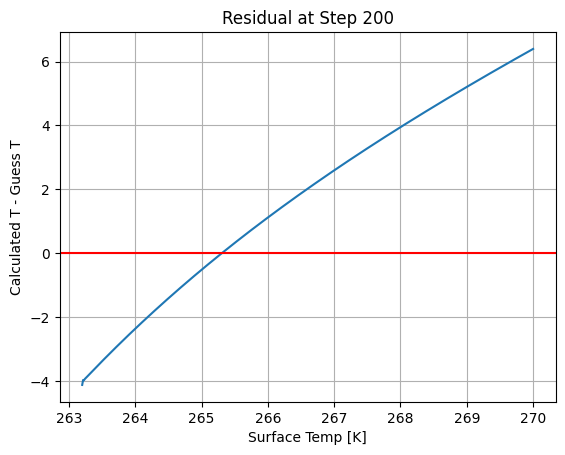

 67%|██████▋   | 336/500 [01:12<00:28,  5.72it/s]

 68%|██████▊   | 338/500 [01:12<00:29,  5.55it/s]

 68%|██████▊   | 340/500 [01:12<00:30,  5.23it/s]

 68%|██████▊   | 342/500 [01:13<00:30,  5.20it/s]

 69%|██████▊   | 343/500 [01:13<00:28,  5.55it/s]

...

 75%|███████▍  | 374/500 [01:19<00:18,  6.86it/s]

 75%|███████▌  | 376/500 [01:19<00:19,  6.40it/s]

 76%|███████▌  | 378/500 [01:19<00:17,  7.05it/s]

 76%|███████▌  | 379/500 [01:20<00:25,  4.74it/s]

Solver crashed at step 379: 'ThermoModel' object has no attribute 'inputs'


Final State:

FrostEvaporatorParameters:
time_step=1.0 s (Simulation time step for evaporator model)
gravity=9.81 m/s^2 (Gravitational acceleration)
frost_density_correlation_choice=jonas_diss - (Choice of correlation for frost density)
frost_thickness_correlation_choice=jonas_diss - (Choice of correlation for frost thickness)
frost_conductivity_correlation_choice=A - (Choice of correlation for frost thermal conductivity)
pressure_loss_fit_factor=50.0 - (Fit factor for air-side pressure loss calculations)
ambient_pressure=101325.0 Pa (Ambient pressure for air-side calculations)
fin_pitch=0.0025 m (Spacing between fins (from center to center))
fin_height=0.152 m (Height of each fin)
fin_length=0.045 m (Length of each fin)
fin_thickness=0.0002 m (Thickness of each fin)
fin_amount=128 - (Total number of fins)
fin_thermal_conductivity=200.0 W/m/K (Thermal conductivity of fin material)
tube_outer_diameter=0.01 m (O

In [2]:
import sys
import os
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import brentq
from tqdm import tqdm

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost import FrostModel
from frost_evaporator.air import AirModel
from frost_evaporator.refrigerant import RefrigerantModel, propane_RP
from frost_evaporator.heat_mass_transfer import HeatMassTransferModel
from frost_evaporator.thermo import ThermoModel



#############################################################################
# Define Parameters
#############################################################################
params = FrostEvaporatorParameters(
    # General
    time_step=1.0,  # [s]
    gravity=9.81,  # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="jonas_diss",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="A",

    # Fan and Air Side Pressure Loss Parameters
    # hydraulic_fan_power=10.0,  # [W] ------------------------------
    pressure_loss_fit_factor=50.0,  # [-] ------------------------------

    # Geometrie Parameters
    # Calculated: 4 fins/cm = 0.25 cm pitch = 2.5 mm
    fin_pitch=0.0025,  # [m]
    # Paper: Height = 152 mm
    fin_height=0.152,  # [m]
    # Paper: Depth (air flow length) = 45 mm
    fin_length=0.045,  # [m]
    # Paper: 0.2 mm thickness
    fin_thickness=0.0002,  # [m]
    # Calculated: Width (320mm) / Pitch (2.5mm) = 128 fins
    fin_amount=128,  # [-]
    # Paper: "Aluminum alloy" (Standard value usually ~200-220)
    fin_thermal_conductivity=200.0,  # [W/mK]
    # Paper: 10 mm Outer Diameter
    tube_outer_diameter=0.010,  # [m]
    # Paper: 1 mm wall thickness -> ID = 10 - 2*1 = 8 mm
    tube_inner_diameter=0.008,  # [m]
    # Paper: "Two rows"
    tube_layers=2,  # [-]
    # Paper: "Six tubes per row"
    tubes_per_layer=6,  # [-]
    # Paper: Copper tubes (Standard value ~385-400)
    tube_thermal_conductivity=400, # [W/mK]

    alpha_0=4300.0,  # [W/m^2K] - 4300 for propane, used for two phase htc (VDI H2 Tab. 1)
)

#############################################################################
# Define Inputs
#############################################################################

# Useless, because Paper uses constant surface temp
refrigerant_inputs = RefrigerantInputs(
    h_in = 0.0,  # [J/kg]
    p_eva = 0.0,  # [Pa]
    m_dot= 0.0,  # [kg/s]
)

# Define the inputs for the frost evaporator
# Values below are for "Test 2" (Standard Commercial conditions from Table 1)
air_inputs = AirInputs(
    # Table 1: Test 2 is 2.5 deg C
    T_in  = 275.65,  # [K]
    # Standard atmospheric pressure assumed (not explicitly stated)
    p_in  = 101325.0,  # [Pa]
    # Table 1: Test 2 is 85% RH @ 2.5 C.
    # Psat(2.5C) ~ 728 Pa. Pv = 0.85 * 728 = 618.8 Pa.
    # W = 0.622 * 618.8 / (101325 - 618.8) = 0.00382
    W_in  = 0.00382,  # [kg/kg]
    )

inputs = FrostEvaporatorInputs(
    air_inputs   = air_inputs,
    refrigerant_inputs = refrigerant_inputs
)



#############################################################################
# Create Models
#############################################################################
frost_model = FrostModel(params)
air_model   = AirModel(params)
refrigerant_model = RefrigerantModel(params, propane_RP)
hmt_model = HeatMassTransferModel(params)
thermo_model = ThermoModel(params)



# Create the initial state
state = FrostEvaporatorState()
state.hmt.set("T_frost_surface", 268)

state.air.set("T_out", inputs.air.T_in)
state.air.set("W_out", inputs.air.W_in)
state.air.set("reynolds", 2000)

state.refrigerant.set("h_out", inputs.refrigerant.h_in + 100.0)


frost_model.step_forward(state, inputs)

states_history = []
T_frost_surface_history_all = []
Q_dot_history_all = []
history_residual = []

def system_residual(T_guess, state_obj, inputs_obj):
    """
    This function represents f(x) = 0.
    1. Sets the guessed T_frost_surface.
    2. Updates all models to consistency.
    3. Returns the energy balance error.
    """
    
    # 1. Force the state to use the solver's guess
    state_obj.hmt.set("T_frost_surface", T_guess)
    
    # 2. Update Frost Properties (Density/Conductivity depend on T_surface)
    frost_model.update_properties(state_obj, inputs_obj)
    
    # 3. Handle Circularity between Air Properties <-> Thermo Outlet Stats
    # We run a mini-loop here to ensure Air Properties (Re, Nu) are consistent 
    # with the T_out that results from the current T_guess.
    # Usually 2-3 iterations are enough for air properties to settle.
    for _ in range(3):
        air_model.update_properties(state_obj, inputs_obj)       # Calculates h_conv, Re based on current T_out
        hmt_model.update_properties(state_obj, inputs_obj)       # Calculates Q_total based on h_conv & T_guess
        thermo_model.update_properties(state_obj, inputs_obj)    # Calculates new T_out based on Q_total
        # refrigerant_model.update... (if needed)

    # 4. Calculate Residual (Energy Balance)
    # We reconstruct the balance equations here to avoid the 'alpha' relaxation 
    # inside your HMT class.
    
    # Heat flowing from Air side (calculated by HMT model)
    Q_flux = state_obj.hmt.Q_dot_total
    
    # Heat flowing to Refrigerant side (Resistance network)
    # Note: Ensure 'R_downstream' includes Frost + Tube + Refrigerant resistances
    R_down = state_obj.hmt.R_downstream 
    
    # We need the Sink Temperature (e.g., Refrigerant Temp or Tube Wall Fixed Temp)
    # Looking at your HMT code, you used a fixed 263.15. 
    # Ideally, this should come from the refrigerant state.
    T_sink = 263.15 # OR: state_obj.refrigerant.T_sat
    
    # The T_frost required to drive Q_flux through R_down
    T_required = T_sink + (Q_flux * R_down)
    
    # Residual = Guess - Required
    # If Guess is too high, Q_flux (Air->Surf) drops, but Q_cond (Surf->Ref) rises.
    return T_guess - T_required

# --- Time Loop ---
for j in tqdm(range(500)):
    
    # Define bounds for the root finder
    # T_surface must be between Refrigerant Temp (Sink) and Air Inlet Temp (Source)
    T_min = 263.15 - 5.0 # Slightly below sink to be safe
    T_max = 273.14
    
    try:
        # Check signs at bounds to prevent Brentq error
        # (Optional but recommended for robustness)
        res_min = system_residual(T_min, state, inputs)
        res_max = system_residual(T_max, state, inputs)
        
        if res_min * res_max > 0:
            # If signs are same, brentq will fail. 
            # Usually means physical limits exceeded or model issues.
            print(f"Bound Error at step {j}: f({T_min})={res_min:.2f}, f({T_max})={res_max:.2f}")
            # Fallback strategy: just use the boundary that is closer to 0
            T_final = T_min if abs(res_min) < abs(res_max) else T_max
        else:
            # --- The Solver ---
            T_final = brentq(
                system_residual, 
                T_min, 
                T_max, 
                args=(state, inputs),
                xtol=1e-3, # Precision tolerance
                maxiter=50
            )
            
    except Exception as e:
        print(f"Solver crashed at step {j}: {e}")
        break

    # Run one final update with the solved temperature to ensure state is perfectly consistent
    # (Brentq might return the root, but the state object might remain at the last iteration inside brentq)
    system_residual(T_final, state, inputs)
    
    # Save History
    states_history.append(state.copy())
    
    # Physical Step Forward (Thickness Integration)
    try:
        frost_model.step_forward(state, inputs)
    except ValueError as e:
        print(f"Simulation ended: {e}") # Catches T > 273.15
        break

    if j == 200 or j == 450:
        test_temps = np.linspace(263.2, 270, 500)
        residuals = []
        for t in test_temps:
            # Note: This changes 'state', so we must reset it after
            r = system_residual(t, state, inputs)
            residuals.append(r)
        
        plt.plot(test_temps, residuals)
        plt.axhline(0, color='red')
        plt.title(f"Residual at Step {j}")
        plt.xlabel("Surface Temp [K]")
        plt.ylabel("Calculated T - Guess T")
        plt.grid(True)
        # plt.xlim([265, 265.1])
        plt.show()
        # Don't forget to stop or pause here!

print("\n\nFinal State:\n")
print(params.__str__())
print("\n\n\n\n")
print(inputs.__str__())
print("\n\n\n\n")
print(state.__str__())

print(3600 * state.air.m_dot_humid / state.air.density_avg)  # Volumenstrom [m³/h]

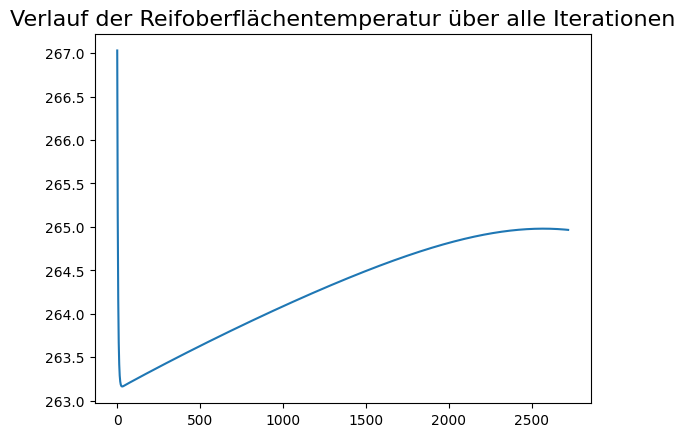

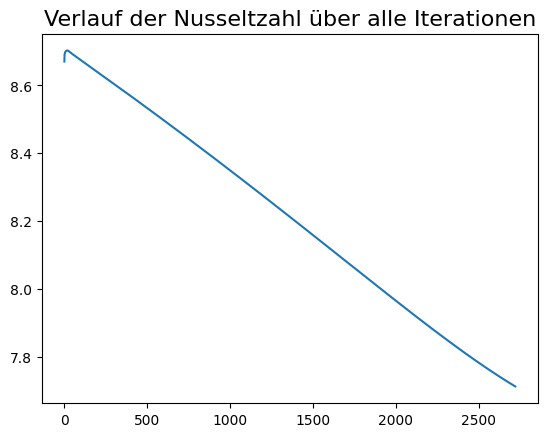

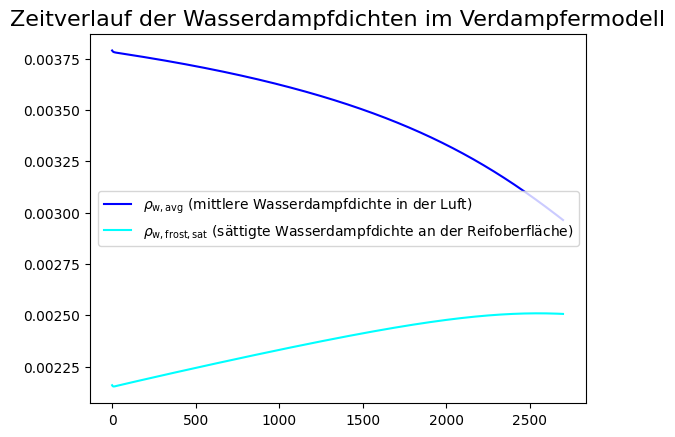

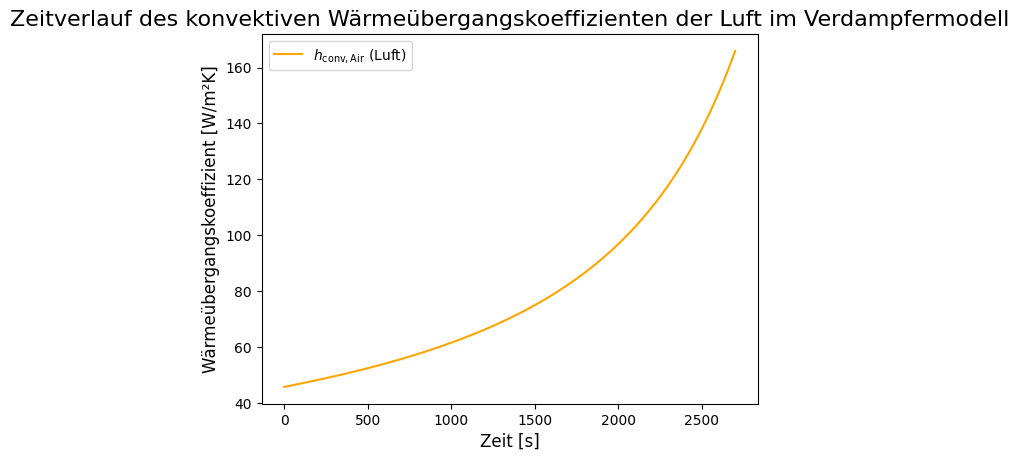

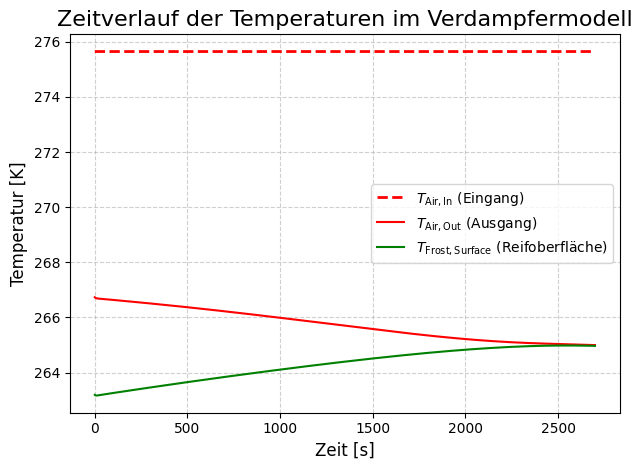

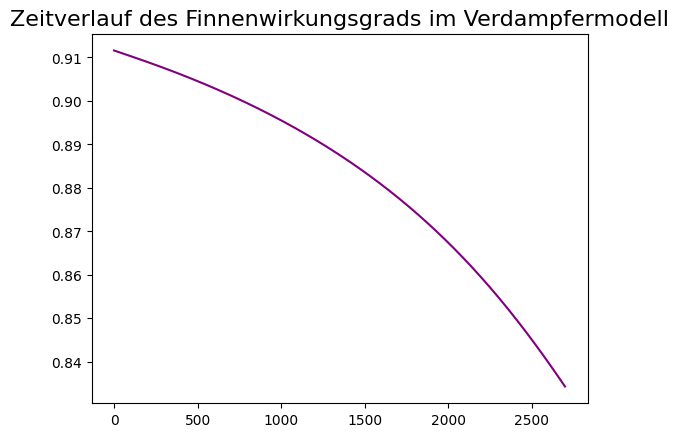

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(T_frost_surface_history_all)
plt.title('Verlauf der Reifoberflächentemperatur über alle Iterationen', fontsize=16)
plt.show()

plt.figure()
plt.plot(nusselt_history_all)
plt.title('Verlauf der Nusseltzahl über alle Iterationen', fontsize=16)
plt.show()


time_steps = list(range(len(states_history))) 

# Extrahieren Sie die Historie für jede Variable
T_out_air_history = [s.air.T_out for s in states_history]
T_refrig_in_history = [s.refrigerant.T_in for s in states_history]
T_refrig_out_history = [s.refrigerant.T_out for s in states_history]
T_frost_surface_history = [s.hmt.T_frost_surface for s in states_history]
eta_fin_history = [s.hmt.eta_fin for s in states_history]
air_h_conv_history = [s.air.h_conv for s in states_history]
air_rho_w_avg_history = [s.air.rho_w_avg for s in states_history]
air_rho_w_frost_sat_history = [s.air.rho_w_frost_sat for s in states_history]

h_refiger_out_history = [s.refrigerant.h_out for s in states_history]

# Erstellen Sie die konstante Linie für T_in_air
T_in_air_constant_line = [inputs.air.T_in] * len(states_history)
h_refrig_in_history = [inputs.refrigerant.h_in] * len(states_history)


plt.figure()
plt.plot(time_steps, air_rho_w_avg_history, label=r'$\rho_{\mathrm{w, avg}}$ (mittlere Wasserdampfdichte in der Luft)', color='blue')
plt.plot(time_steps, air_rho_w_frost_sat_history, label=r'$\rho_{\mathrm{w, frost, sat}}$ (sättigte Wasserdampfdichte an der Reifoberfläche)', color='cyan')
plt.title('Zeitverlauf der Wasserdampfdichten im Verdampfermodell', fontsize=16)
plt.legend()
plt.show()



plt.figure()
plt.plot(time_steps, air_h_conv_history, label=r'$h_{\mathrm{conv, Air}}$ (Luft)', color='orange')
plt.title('Zeitverlauf des konvektiven Wärmeübergangskoeffizienten der Luft im Verdampfermodell', fontsize=16)
plt.xlabel('Zeit [s]', fontsize=12)
plt.ylabel('Wärmeübergangskoeffizient [W/m²K]', fontsize=12)
plt.legend()
plt.show()

# ----------------------------------------------------------------------
# Plot-Erstellung

plt.figure()

# Plotten Sie die verschiedenen Temperaturverläufe
plt.plot(time_steps, T_in_air_constant_line, label=r'$T_{\mathrm{Air, In}}$ (Eingang)', linestyle='--', color='red', linewidth=2)
plt.plot(time_steps, T_out_air_history, label=r'$T_{\mathrm{Air, Out}}$ (Ausgang)', color='red')
plt.plot(time_steps, T_frost_surface_history, label=r'$T_{\mathrm{Frost, Surface}}$ (Reifoberfläche)', color='green')
# plt.plot(time_steps, T_refrig_in_history, label=r'$T_{\mathrm{Refrig, In}}$ (Kältemittel Eingang)', color='blue', linestyle='--')
# plt.plot(time_steps, T_refrig_out_history, label=r'$T_{\mathrm{Refrig, Out}}$ (Kältemittel Ausgang)', color='blue')#, linestyle=':')

# Beschriftung und Layout
plt.title('Zeitverlauf der Temperaturen im Verdampfermodell', fontsize=16)
plt.xlabel('Zeit [s]', fontsize=12)
plt.ylabel('Temperatur [K]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(time_steps, eta_fin_history, label=r'$\eta_{\mathrm{fin}}$ (Finnenwirkungsgrad)', color='purple')
plt.title('Zeitverlauf des Finnenwirkungsgrads im Verdampfermodell', fontsize=16)
plt.show()


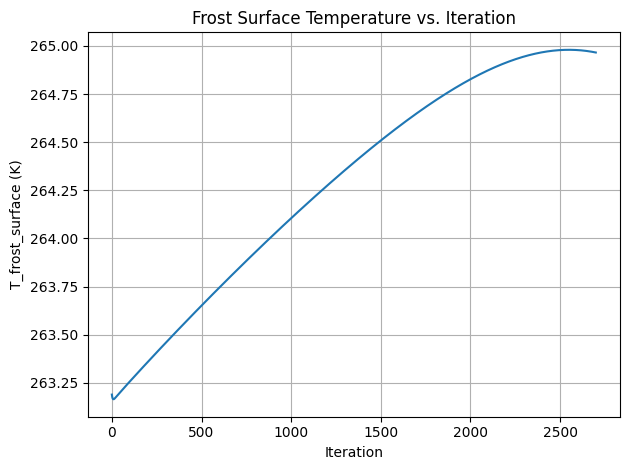

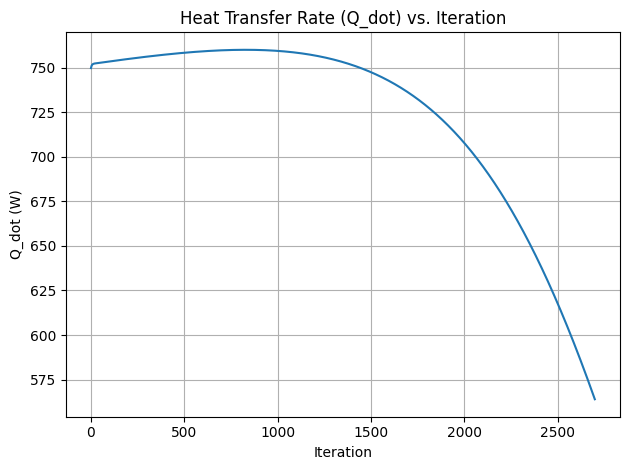

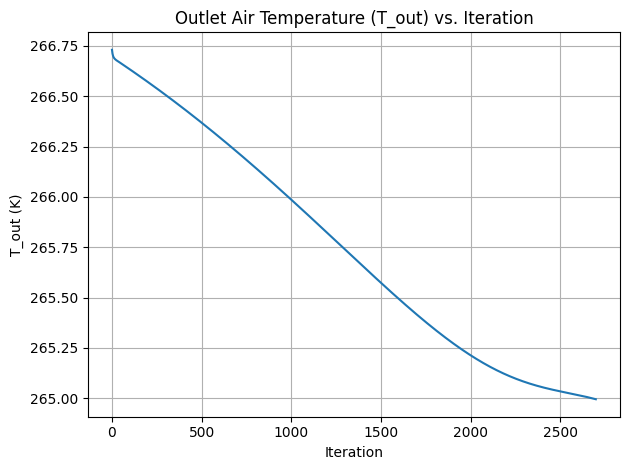

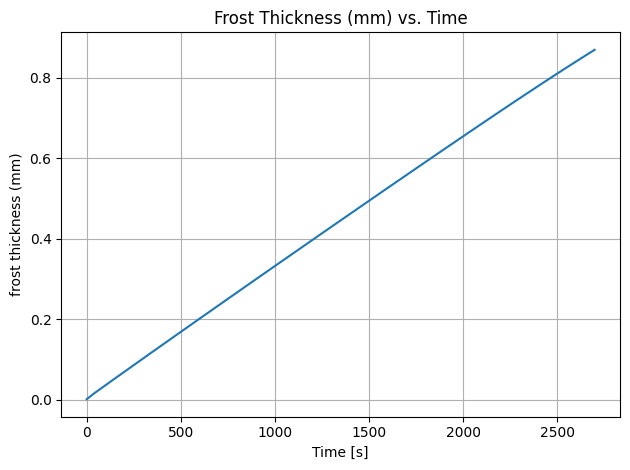

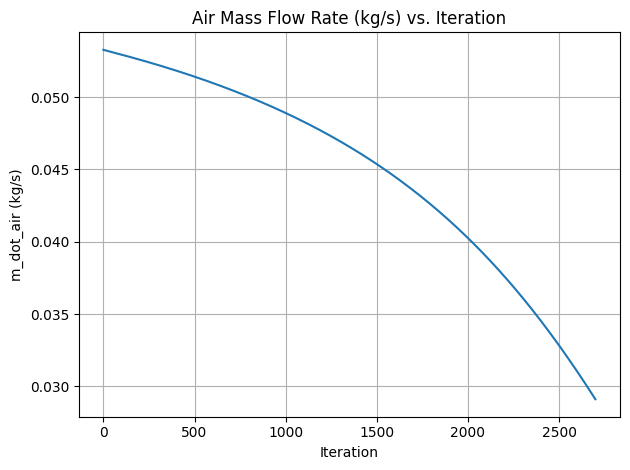

In [3]:
#############################################################################
# Extract Data for Plotting
#############################################################################
# Create an x-axis (iterations)

iterations = range(len(states_history))

# Extract the history for each variable
T_frost_surface_history = [s.hmt.T_frost_surface for s in states_history]
Q_dot_total_history = [s.hmt.Q_dot_total for s in states_history]
T_out_history = [s.air.T_out for s in states_history]
thickness_history = [s.frost.thickness*1000 for s in states_history]
m_flow_air_history = [s.air.m_dot_dry for s in states_history]

#############################################################################
# Generate Plots
#############################################################################

# Plot 1: state.hmt.T_frost_surface
plt.figure() # Create a new figure
plt.plot(iterations, T_frost_surface_history)
plt.xlabel("Iteration")
plt.ylabel("T_frost_surface (K)")
plt.ticklabel_format(style="plain", useOffset=False)
plt.title("Frost Surface Temperature vs. Iteration")
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot 2: state.hmt.Q_dot
plt.figure()
plt.plot(iterations, Q_dot_total_history)
plt.xlabel("Iteration")
plt.ylabel("Q_dot (W)")
plt.ticklabel_format(style="plain", useOffset=False)
plt.title("Heat Transfer Rate (Q_dot) vs. Iteration")
plt.grid(True)
plt.tight_layout()
plt.show()



# Plot 4: state.air.T_out
plt.figure()
plt.plot(iterations, T_out_history)
plt.xlabel("Iteration")
plt.ylabel("T_out (K)")
plt.ticklabel_format(style="plain", useOffset=False)
plt.title("Outlet Air Temperature (T_out) vs. Iteration")
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot 5: state.refrigerant.h_out
plt.figure()
plt.plot(iterations, thickness_history)
plt.xlabel("Time [s]")
plt.ylabel("frost thickness (mm)")
plt.ticklabel_format(style="plain", useOffset=False)
plt.title("Frost Thickness (mm) vs. Time")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(iterations, m_flow_air_history)
plt.xlabel("Iteration")
plt.ylabel("m_dot_air (kg/s)")
plt.ticklabel_format(style="plain", useOffset=False)
plt.title("Air Mass Flow Rate (kg/s) vs. Iteration")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import sys
import os
import numpy as np
from matplotlib import pyplot as plt

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost import FrostModel
from frost_evaporator.air import AirModel

# Define the parameters for the frost evaporator
params = FrostEvaporatorParameters(
    # Time
    time_step=1.0,  # [s]

    gravity=9.81,  # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="jonas_diss",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="A",

    # Fan and Air Side Pressure Loss Parameters
    hydraulic_fan_power=50.0,  # [W]
    pressure_loss_fit_factor=1.0,  # [-]

    # Geometrie Parameters
    fin_pitch=0.004,  # [m]
    fin_height=0.4,  # [m]
    fin_length=0.8,  # [m]
    fin_thickness=0.0002,  # [m]
    fin_amount=60,  # [-]
    fin_thermal_conductivity=200.0,  # [W/mK]
    tube_outer_diameter=0.010,  # [m]
    tube_inner_diameter=0.006,  # [m]
    tube_layers=5,  # [-]
    tubes_per_layer=4,  # [-]

    alpha_0=4300.0,  # [W/m^2K] - 4300 for propane, used for two phase htc (VDI H2 Tab. 1)
)



refrigerant_inputs = RefrigerantInputs(
    h_in = 400000.0,  # [J/kg]
    p_eva = 5e5,  # [Pa]
    m_dot= 0.02,  # [kg/s]
)
air_inputs = AirInputs(
    T_in  = 273.15,  # [K]
    p_in  = 101325.0,  # [Pa]
    W_in  = 0.001,  # [kg/kg]
)

state = FrostEvaporatorState()

state.refrigerant.h_out = 400000.0  # [J/kg]

inputs = FrostEvaporatorInputs(
    air_inputs   = air_inputs,
    refrigerant_inputs = refrigerant_inputs
)

from frost_evaporator.refrigerant import RefrigerantModel, propane_RP
# Create the models

refrigerant_model = RefrigerantModel(params, propane_RP)

refrigerant_model.update_properties(state, inputs)

state.refrigerant.h_conv

In [ ]:
# Create the initial state
state = FrostEvaporatorState()
state.hmt.set("m_dot_frost_flux", 2e-4) # kg/m^2/s

# Temperature sweep from 265K to 270K
temperatures_frost = np.linspace(265, 270, 100)

# Arrays to store results
thicknesses = []
densitys    = []
k_frosts    = []
flow_areas_air        = []

for T_frost in temperatures_frost:
    # Update the Frost Temperature - would be done by hmt.py
    state.hmt.set("T_frost_surface", T_frost)

    # Blue Boxes (This will be in a Iterative Loop later)
    frost_model.update_properties(state, inputs)

    # Green Boxes (Update after 1s timestep)
    frost_model.step_forward(state, inputs)

    # Store the results
    thicknesses.append(state.frost.thickness)
    densitys.append(state.frost.density)
    k_frosts.append(state.frost.k_frost)
    flow_areas_air.append(state.frost.flow_area_air)



fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

axs[0].plot(thicknesses, marker='.', linestyle='-')
axs[0].set_ylabel("Thickness (m)")

axs[1].plot(densitys, marker='.', linestyle='-')
axs[1].set_ylabel("Density (kg/m³)")

axs[2].plot(k_frosts, marker='.', linestyle='-')
axs[2].set_ylabel("k_frost (W/mK)")
axs[2].set_xlabel("Time (s)")

axs[3].plot(flow_areas_air, marker='.', linestyle='-')
axs[3].set_ylabel("Air Flow Area (m²)")
axs[3].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()